# Identificação do Aeropêndulo com Neural ODEs - Multi-Experimentos (v2.0)
Nesta versão do notebook, treinaremos os modelos baseados em Equações Diferenciais (Caixa-Cinza e Caixa-Preta) utilizando **múltiplos conjuntos de dados simultaneamente**.
Isso expõe a rede a dinâmicas mais variadas (degraus, chirp, multi-senos), gerando um modelo mais robusto e generalista.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
from scipy.signal import savgol_filter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Carregando datasets de TREINO...
 -> multi-seno-2_0804_19-31.csv carregado com 1400 amostras.
 -> chirp-1_0804_19-19.csv carregado com 801 amostras.
 -> seq-degraus-2_0804_19-38.csv carregado com 1400 amostras.

Carregando dataset de TESTE...
 -> multi-seno-1_0804_19-06.csv carregado com 800 amostras.


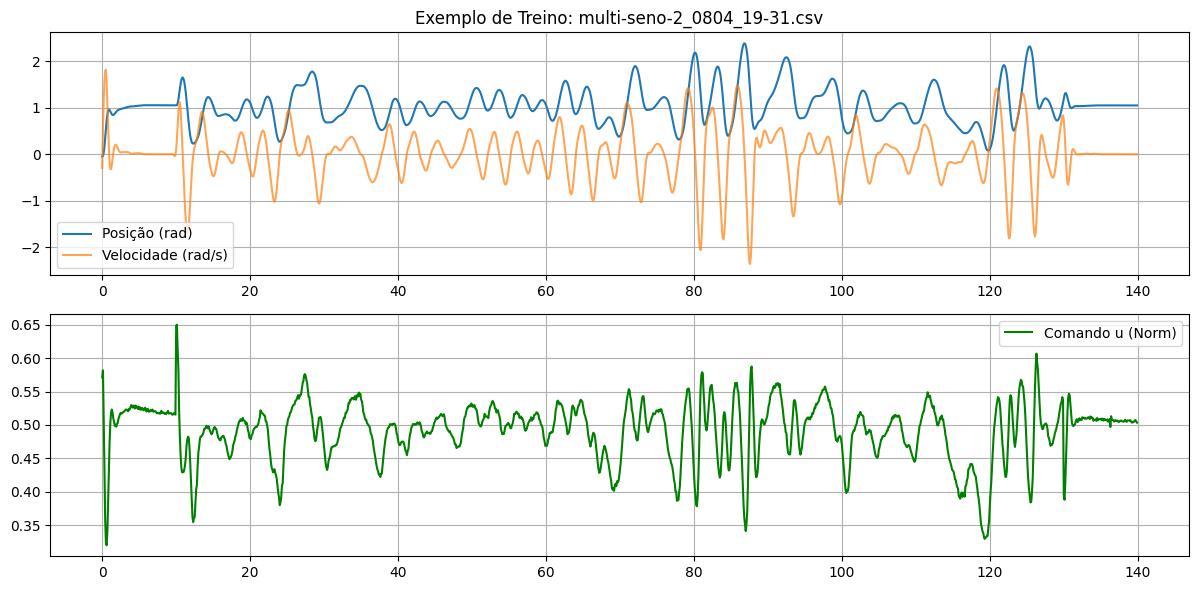

In [ ]:
def carregar_experimento(url, decimacao=1):
    df = pd.read_csv(url)
    if 'referencia' in df.columns:
        df = df[df['referencia'] > 0]
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)

    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values

    y_raw = df_sub['angulo_deg'].values

    # Geramos um vetor de tempo sintético estritamente crescente (~10ms originais)
    dt = 0.010 * decimacao
    t_raw = np.arange(len(y_raw)) * dt

    return t_raw, u_raw, y_raw

def processar_dataset(t_raw, u_raw, y_raw):
    # Forçar o tempo inicial para zero
    t_raw = t_raw - t_raw[0]

    # Conversão para radianos (mundo físico)
    y_rad = y_raw * (np.pi / 180.0)

    # Normalização da entrada u (0 a 100% -> 0 a 1)
    u_norm = u_raw / 100.0

    # Derivação com Savitzky-Golay
    dt_mean = np.mean(np.diff(t_raw))
    window = 11
    poly = 3
    v_rad_s = savgol_filter(y_rad, window, poly, deriv=1, delta=dt_mean)

    # Matriz de estados x = [posição, velocidade]
    x_matrix = np.vstack((y_rad, v_rad_s)).T

    return (torch.tensor(t_raw, dtype=torch.float32),
            torch.tensor(u_norm, dtype=torch.float32).unsqueeze(1),
            torch.tensor(x_matrix, dtype=torch.float32),
            y_rad, v_rad_s, u_norm)

BASE2 = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

# Arquivos utilizados para treino (variações ricas de dinâmica)
train_files = [
    "RODADA-2/multi-seno-2_0804_19-31.csv",
    "RODADA-2/multi-seno-1_0804_19-06.csv",
    "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "RODADA-2/multi-seno-3_0804_19-44.csv",
    "RODADA-2/seq-degraus-1_0804_19-12.csv"
]
# Testaremos a generalização em um arquivo nunca visto no treino
test_file = "RODADA-2/chirp-1_0804_19-19.csv"

decimacao = 5

print("Carregando datasets de TREINO...")
train_datasets = []
for f in train_files:
    t_raw, u_raw, y_raw = carregar_experimento(BASE2 + f, decimacao=decimacao)
    t_ten, u_ten, x_ten, y_rad, v_rad, u_norm = processar_dataset(t_raw, u_raw, y_raw)
    train_datasets.append({
        'name': f,
        't': t_ten, 'u': u_ten, 'x': x_ten,
        'y_rad': y_rad, 'v_rad': v_rad, 'u_norm': u_norm
    })
    print(f" -> {f} carregado com {len(t_ten)} amostras.")

print("\nCarregando dataset de TESTE...")
t_raw, u_raw, y_raw = carregar_experimento(BASE2 + test_file, decimacao=decimacao)
t_test, u_test, x_test, y_rad_t, v_rad_t, u_norm_t = processar_dataset(t_raw, u_raw, y_raw)
print(f" -> {test_file} carregado com {len(t_test)} amostras.")

# Visualizando um dos datasets de treino
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(train_datasets[0]['t'], train_datasets[0]['y_rad'], label='Posição (rad)')
plt.plot(train_datasets[0]['t'], train_datasets[0]['v_rad'], label='Velocidade (rad/s)', alpha=0.7)
plt.title(f"Exemplo de Treino: {train_datasets[0]['name']}")
plt.grid(); plt.legend()

plt.subplot(2,1,2)
plt.plot(train_datasets[0]['t'], train_datasets[0]['u_norm'], label='Comando u (Norm)', color='green')
plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
# 1. MODELOS ODE (NODE)
class PhysicsODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.m1, self.L1 = 0.122, 0.39
        self.m2, self.L2 = 0.055, 0.347
        self.g = 9.81

        # Parâmetros Desconhecidos: Inércia (J), Atrito (b), Ganho do Motor (Gu)
        self.log_J = nn.Parameter(torch.tensor(0.0))
        self.log_b = nn.Parameter(torch.tensor(-1.0))
        self.log_Gu = nn.Parameter(torch.tensor(0.0))

        self.u_series = None
        self.t_series = None
        self.batch_start_times = None

    def get_params(self):
        return torch.exp(self.log_J), torch.exp(self.log_b), torch.exp(self.log_Gu)

    def forward(self, t, x):
        J, b, Gu = self.get_params()

        p1 = b / J
        p2 = ((self.m1 * self.L1 - self.m2 * self.L2) * self.g) / J
        p3 = Gu / J

        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])

        k = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k = torch.clamp(k, 1, len(self.t_series) - 1)

        t1, t2 = self.t_series[k-1].unsqueeze(1), self.t_series[k].unsqueeze(1)
        u1, u2 = self.u_series[k-1], self.u_series[k]

        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        u_t = u1 + alpha * (u2 - u1)

        theta, theta_dot = x[:, 0:1], x[:, 1:2]
        theta_ddot = - p1 * theta_dot - p2 * torch.sin(theta) + p3 * (u_t ** 2)

        return torch.cat([theta_dot, theta_ddot], dim=1)


class BlackBoxODE(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        self.u_series = None
        self.t_series = None
        self.batch_start_times = None

    def forward(self, t, x):
        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])

        k = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k = torch.clamp(k, 1, len(self.t_series) - 1)

        t1, t2 = self.t_series[k-1].unsqueeze(1), self.t_series[k].unsqueeze(1)
        u1, u2 = self.u_series[k-1], self.u_series[k]

        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        u_t = u1 + alpha * (u2 - u1)

        nn_input = torch.cat([x, u_t], dim=1)
        return self.net(nn_input)

In [ ]:
# 2. FUNÇÃO DE TREINAMENTO (MULTI-DATASET)
def train_model_multi(model, name, datasets, epochs=1000, lr=0.01, k_steps=20):
    print(f"--- Iniciando Treinamento: {name} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    BATCH_SIZE = 8192

    # Assume-se dt igual para todos os datasets (pois vieram da mesma bancada e dízima)
    dt = (datasets[0]['t'][1] - datasets[0]['t'][0]).item()
    t_eval = torch.arange(0, k_steps * dt, dt, device=device)

    for epoch in range(epochs + 1):
        optimizer.zero_grad()

        # Sorteia qual dataset será usado para este batch
        ds = np.random.choice(datasets)
        t_ds = ds['t'].to(device)
        u_ds = ds['u'].to(device)
        x_ds = ds['x'].to(device)

        # Alimenta os dados temporais deste dataset ao modelo
        model.t_series = t_ds
        model.u_series = u_ds

        # Seleciona pontos de partida aleatórios
        start_idx = np.random.randint(0, len(t_ds) - k_steps, size=BATCH_SIZE)
        x0 = x_ds[start_idx]
        model.batch_start_times = t_ds[start_idx].reshape(-1, 1)

        # Integração (Rollout)
        pred_state = odeint(model, x0, t_eval, method='rk4')

        # Compara com o alvo
        batch_targets = []
        for i in start_idx:
            batch_targets.append(x_ds[i:i+k_steps])
        y_target = torch.stack(batch_targets, dim=1)

        loss = torch.mean((pred_state - y_target)**2)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

    return model

In [ ]:
# Treinando o modelo Físico
phys_model = PhysicsODE()
phys_model = train_model_multi(phys_model, "Physics-Informed Model (Caixa-Cinza)", train_datasets, epochs=2500, lr=0.02, k_steps=20)

J, b, Gu = phys_model.get_params()
print("\nParâmetros Físicos Encontrados:")
print(f"J (Inércia): {J.item():.4f} kg.m^2")
print(f"b (Atrito): {b.item():.4f}")
print(f"Gu (Ganho Motor): {Gu.item():.4f}\n")

# Treinando o modelo Caixa-Preta (MLP)
bb_model = BlackBoxODE(hidden_dim=32)
bb_model = train_model_multi(bb_model, "Black-Box Model (MLP)", train_datasets, epochs=2500, lr=0.01, k_steps=20)

--- Iniciando Treinamento: Physics-Informed Model (Caixa-Cinza) ---
Epoch    0 | Loss: 0.286577
Epoch  100 | Loss: 0.137396
Epoch  200 | Loss: 0.112161
Epoch  300 | Loss: 0.032700
Epoch  400 | Loss: 0.043672
Epoch  500 | Loss: 0.029077
Epoch  600 | Loss: 0.037617
Epoch  700 | Loss: 0.028456
Epoch  800 | Loss: 0.029876
Epoch  900 | Loss: 0.161382
Epoch 1000 | Loss: 0.097455


KeyboardInterrupt: 

In [ ]:
# 3. VALIDAÇÃO FREE-RUN NO CONJUNTO DE TESTE
print("\n--- Simulação Free-Run no Conjunto de TESTE (nunca visto no treino) ---")

with torch.no_grad():
    phys_model.u_series = u_test.to(device)
    phys_model.t_series = t_test.to(device)
    phys_model.batch_start_times = torch.zeros(1, 1).to(device)

    bb_model.u_series = u_test.to(device)
    bb_model.t_series = t_test.to(device)
    bb_model.batch_start_times = torch.zeros(1, 1).to(device)

    x0_test_t = x_test[0].unsqueeze(0).to(device)

    full_pred_phys = odeint(phys_model, x0_test_t, t_test.to(device), method='rk4').squeeze(1).cpu().numpy()
    full_pred_bb = odeint(bb_model, x0_test_t, t_test.to(device), method='rk4').squeeze(1).cpu().numpy()

# Graus para plotagem
y_test_deg_real = x_test[:, 0].numpy() * (180.0 / np.pi)
phys_deg_pred = full_pred_phys[:, 0] * (180.0 / np.pi)
bb_deg_pred = full_pred_bb[:, 0] * (180.0 / np.pi)
t_test_np = t_test.numpy()

from sklearn.metrics import mean_squared_error
rmse_phys = np.sqrt(mean_squared_error(y_test_deg_real, phys_deg_pred))
rmse_bb = np.sqrt(mean_squared_error(y_test_deg_real, bb_deg_pred))

print(f"Physics-Informed -> RMSE: {rmse_phys:.2f}°")
print(f"Black-Box        -> RMSE: {rmse_bb:.2f}°\n")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t_test_np, y_test_deg_real, 'k-', linewidth=2, label='Real (Teste)')
plt.plot(t_test_np, phys_deg_pred, 'r--', linewidth=2, label='Physics-Informed')
plt.title("Validação Free-Run: Posição (Ângulo)")
plt.ylabel("Ângulo (graus)")
plt.xlabel("Tempo (s)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_test_np, y_test_deg_real, 'k-', linewidth=2, label='Real (Teste)')
plt.plot(t_test_np, bb_deg_pred, 'b--', linewidth=2, label='Black-Box')
plt.title("Validação Free-Run: Posição (Ângulo)")
plt.ylabel("Ângulo (graus)")
plt.xlabel("Tempo (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- Salvando os modelos na máquina ---
import torch

caminho_cinza = 'node_caixa_cinza.pth'
torch.save(phys_model.state_dict(), caminho_cinza)
print(f'Modelo Físico (Caixa-Cinza) salvo em: {caminho_cinza}')

caminho_preta = 'node_caixa_preta.pth'
torch.save(bb_model.state_dict(), caminho_preta)
print(f'Modelo Neural (Caixa-Preta) salvo em: {caminho_preta}')